# KNN

In [ ]:
import numpy as np
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# Load the iris dataset
iris_X, iris_y = datasets.load_iris(return_X_y=True)

# Split train:test = 8:2
X_train, X_test, y_train, y_test = train_test_split(
    iris_X,
    iris_y,
    test_size=0.2,
    random_state=42
)

# Scale the features using StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Build KNN Classifier
knn_classifier = KNeighborsClassifier(n_neighbors=5)
knn_classifier.fit(X_train, y_train)

# Predict and Evaluate test set
y_pred = knn_classifier.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

accuracy

# K-Means Clustering

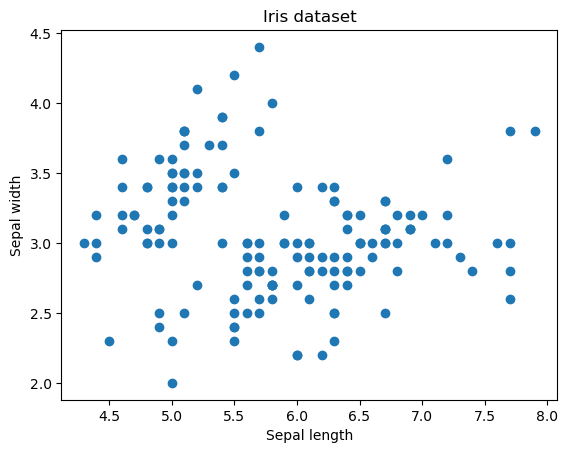

In [1]:
from sklearn.datasets import load_iris
import numpy as np
import matplotlib.pyplot as plt

iris_dataset = load_iris()
data = iris_dataset.data[:, :2]

plt.scatter(data[:, 0], data[:, 1])
plt.xlabel('Sepal length')
plt.ylabel('Sepal width')
plt.title('Iris dataset')
plt.show()

In [12]:
def euclidean_distance(x1, x2):
    return np.sqrt(np.sum((x1 - x2) ** 2))

k1 = np.array([2, 3, 1.5])
k2 = np.array([1, 2, 1])

numbers = [
    3.0, 3.5, 2.0, 3.5, 3.0, 2.5, 8.0, 8.0, 7.5, 8.5, 8.5, 8.0, 9.0, 8.0, 8.5, 1.5, 2.5, 1.5
]

# Convert the list to a NumPy array
array = np.array(numbers)

# Reshape the array to 7x3
reshaped_array = array.reshape(7, 3)

x = np.array([3, 3.5, 2])
print(euclidean_distance(x, k1))
print(euclidean_distance(x, k2))

1.224744871391589
2.692582403567252


In [27]:
class KMeans:
    def __init__(self, k=3, max_iter=100):
        self.k = k
        self.max_iter = max_iter
        self.centroids = None
        self.clusters = None
        
    def initialize_centroids(self, data):
        np.random.seed(42)
        self.centroids = data[np.random.choice(data.shape[0], self.k, replace=False)]
        
    def euclidean_distance(self, x1, x2):
        return np.sqrt(np.sum((x1 - x2) ** 2))
    
    def assign_clusters(self, data):
        distances = np.array([[self.euclidean_distance(x, c) for c in self.centroids] for x in data])
        res = np.argmin(distances, axis=1)
        print(res)
        return res
    
    def update_centroids(self, data):
        return np.array([data[self.clusters == i].mean(axis=0) for i in range(self.k)])
    
    def fit(self, data):
        self.initialize_centroids(data)
        
        for i in range(self.max_iter):
            self.clusters = self.assign_clusters(data)
            self.plot_clusters(data, i)
            
            new_centroids = self.update_centroids(data)
            
            if np.all(self.centroids == new_centroids):
                break
            
            self.centroids = new_centroids
        
        
        self.plot_final_clusters(data)
        print(self.centroids)

    def plot_clusters(self, data, iteration):
        plt.scatter(data[:, 0], data[:, 1], c=self.clusters, cmap='viridis', marker='o', alpha=0.6)
        plt.scatter(self.centroids[:, 0], self.centroids[:, 1], s=300, c='red', marker='x')
        plt.title(f"Iteration {iteration + 1}")
        plt.xlabel('Sepal length')
        plt.ylabel('Sepal width')
        plt.show()

    def plot_final_clusters(self, data):
        plt.scatter(data[:, 0], data[:, 1], c=self.clusters, cmap='viridis', marker='o', alpha=0.6)
        plt.scatter(self.centroids[:, 0], self.centroids[:, 1], s=300, c='red', marker='x')
        plt.title("Final Clusters and Centroids")
        plt.xlabel('Sepal length')
        plt.ylabel('Sepal width')
        plt.show()